In [ ]:
#Mount the dirve
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import nltk
import spacy

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA
from wordcloud import WordCloud

from collections import Counter
from spacy import displacy


nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

!pip install gensim
from gensim.models import Word2Vec

!pip install pyspellchecker
from spellchecker import SpellChecker

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 84.6 MB/s eta 0:00:00


In [ ]:
#Import the dataset and present the first 5 rows
df = pd.read_csv("/content/drive/MyDrive/NLP Project/amazon_reviews.csv")

### **TASK 2:**

In [ ]:
# Show the first 5 rows of the dataset
df.head()


,reviewId,userName,content,score,thumbsUpCount,reviewCreatedVersion,at,appVersion
0,b00cac20-ed09-4368-8e3a-13b9b181d9a5,Michael Simmons,awesome 👍,5,0,30.22.0.100,2025-12-20 10:35:11,30.22.0.100
1,eba2e27b-cf41-4c64-a0da-b7819f887e40,Rahamtullah Khan,bad,1,0,30.22.2.100,2025-12-20 10:27:54,30.22.2.100
2,664ca9b7-93ae-438a-9102-a2da47ba31c1,Alda Wright,"Convenience, Convenience, Convenience!!!",5,0,30.22.0.100,2025-12-20 09:47:31,30.22.0.100
3,1eceb57e-21e8-4b53-af01-a5096127d3ec,Zak Cullen,Terrible app and super difficult with changing...,2,0,30.22.2.100,2025-12-20 09:30:19,30.22.2.100
4,457773fe-ce0f-4849-b460-be2b02c7cda0,Luna K,nifty app,5,0,30.22.0.100,2025-12-20 09:17:31,30.22.0.100


In [ ]:
# Show Dataset shape
df.shape

(82449, 8)

In [ ]:
# Show dataset columns
df.columns

Index(['reviewId', 'userName', 'content', 'score', 'thumbsUpCount',
       'reviewCreatedVersion', 'at', 'appVersion'],
      dtype='object')

In [ ]:
# Check the missing values
df.isnull().sum()

,0
reviewId,0
userName,6
content,6
score,0
thumbsUpCount,0
reviewCreatedVersion,9395
at,0
appVersion,9395


In [ ]:
# Lable the data into sentiment classes
def sentiment_label(rating):
    if rating <= 2:
        return 'Negative'
    elif rating == 3:
        return 'Neutral'
    else:
        return 'Positive'

df['sentiment'] = df['score'].apply(sentiment_label)

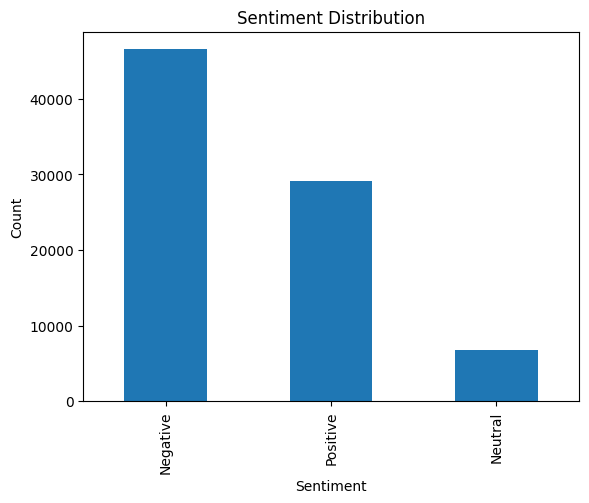

In [ ]:
# Visualize the lable distribution

df['sentiment'].value_counts().plot(kind='bar')
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

### **TASK 3:**

In [ ]:
# Lowercasing
df['lower_text'] = df['content'].str.lower()

df[['content', 'lower_text']].head()

,content,lower_text
0,awesome 👍,awesome 👍
1,bad,bad
2,"Convenience, Convenience, Convenience!!!","convenience, convenience, convenience!!!"
3,Terrible app and super difficult with changing...,terrible app and super difficult with changing...
4,nifty app,nifty app


In [ ]:
# Emojies removal
def remove_emojis(text):
    emoji_pattern = re.compile(
        "["
        u"\U0001F600-\U0001F64F"
        u"\U0001F300-\U0001F5FF"
        u"\U0001F680-\U0001F6FF"
        u"\U0001F1E0-\U0001F1FF"
        "]+",
        flags=re.UNICODE
    )
    # Convert text to string to handle non-string inputs like NaN
    return emoji_pattern.sub(r'', str(text))

df['no_emoji_text'] = df['lower_text'].apply(remove_emojis)

df[['lower_text', 'no_emoji_text']].head()

,lower_text,no_emoji_text
0,awesome 👍,awesome
1,bad,bad
2,"convenience, convenience, convenience!!!","convenience, convenience, convenience!!!"
3,terrible app and super difficult with changing...,terrible app and super difficult with changing...
4,nifty app,nifty app


In [ ]:
# Remove Punctuation & Numbers
def remove_punctuation_numbers(text):
    return re.sub(r'[^a-z\s]', '', text)

df['clean_text'] = df['no_emoji_text'].apply(remove_punctuation_numbers)

df[['no_emoji_text', 'clean_text']].head()

,no_emoji_text,clean_text
0,awesome,awesome
1,bad,bad
2,"convenience, convenience, convenience!!!",convenience convenience convenience
3,terrible app and super difficult with changing...,terrible app and super difficult with changing...
4,nifty app,nifty app


In [ ]:
# Tokenization
df['tokens'] = df['clean_text'].apply(word_tokenize)

df[['clean_text', 'tokens']].head()

,clean_text,tokens
0,awesome,[awesome]
1,bad,[bad]
2,convenience convenience convenience,"[convenience, convenience, convenience]"
3,terrible app and super difficult with changing...,"[terrible, app, and, super, difficult, with, c..."
4,nifty app,"[nifty, app]"


In [ ]:
# Stopword Removal
def remove_stopwords(text):
    stop_words = set(stopwords.words("english"))
    tokens = word_tokenize(text)
    filtered_tokens = [word for word in tokens if word not in stop_words]
    return filtered_tokens

df['tokens_no_stopwords'] = df['tokens'].apply(
    lambda tokens: [word for word in tokens if word not in stop_words])

df[['tokens', 'tokens_no_stopwords']].head()

,tokens,tokens_no_stopwords
0,[awesome],[awesome]
1,[bad],[bad]
2,"[convenience, convenience, convenience]","[convenience, convenience, convenience]"
3,"[terrible, app, and, super, difficult, with, c...","[terrible, app, super, difficult, changing, ad..."
4,"[nifty, app]","[nifty, app]"


In [ ]:
# Stemming
stemmer = PorterStemmer()

df['stemmed_tokens'] = df['tokens_no_stopwords'].apply(
    lambda tokens: [stemmer.stem(word) for word in tokens]
)

df[['tokens_no_stopwords', 'stemmed_tokens']].head()

,tokens_no_stopwords,stemmed_tokens
0,[awesome],[awesom]
1,[bad],[bad]
2,"[convenience, convenience, convenience]","[conveni, conveni, conveni]"
3,"[terrible, app, super, difficult, changing, ad...","[terribl, app, super, difficult, chang, addres..."
4,"[nifty, app]","[nifti, app]"


In [ ]:
# Lemmatization
lemmatizer = WordNetLemmatizer()

df['lemmatized_tokens'] = df['stemmed_tokens'].apply(
    lambda tokens: [lemmatizer.lemmatize(word) for word in tokens]
)

df[['stemmed_tokens', 'lemmatized_tokens']].head()

,stemmed_tokens,lemmatized_tokens
0,[awesom],[awesom]
1,[bad],[bad]
2,"[conveni, conveni, conveni]","[conveni, conveni, conveni]"
3,"[terribl, app, super, difficult, chang, addres...","[terribl, app, super, difficult, chang, addres..."
4,"[nifti, app]","[nifti, app]"


In [ ]:
# Final text
df['final_text'] = df['lemmatized_tokens'].apply(lambda x: ' '.join(x))

df[['content', 'final_text']].head()

,content,final_text
0,awesome 👍,awesom
1,bad,bad
2,"Convenience, Convenience, Convenience!!!",conveni conveni conveni
3,Terrible app and super difficult with changing...,terribl app super difficult chang address card...
4,nifty app,nifti app


## **EXTRA STEP**

In [ ]:
# Extra step 'SkipGram'
text_col = 'final_text' if 'final_text' in df.columns else 'clean_text'

sentences = df[text_col].dropna().astype(str).apply(word_tokenize).tolist()

# Remove very short sentences
sentences = [s for s in sentences if len(s) >= 2]


In [ ]:
# Train for skipgram
skipgram_model = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=5,
    workers=4,
    sg=1  # sg=1 => Skip-gram, sg=0 => CBOW
)

skipgram_model.wv.key_to_index  # vocabulary words

{'app': 0,
 'amazon': 1,
 'order': 2,
 'get': 3,
 'use': 4,
 'item': 5,
 'time': 6,
 'shop': 7,
 'dont': 8,
 'cant': 9,
 'prime': 10,
 'servic': 11,
 'deliveri': 12,
 'updat': 13,
 'custom': 14,
 'day': 15,
 'product': 16,
 'like': 17,
 'work': 18,
 'even': 19,
 'im': 20,
 'tri': 21,
 'need': 22,
 'love': 23,
 'go': 24,
 'search': 25,
 'good': 26,
 'make': 27,
 'ship': 28,
 'great': 29,
 'want': 30,
 'account': 31,
 'one': 32,
 'back': 33,
 'thing': 34,
 'never': 35,
 'buy': 36,
 'phone': 37,
 'keep': 38,
 'find': 39,
 'price': 40,
 'say': 41,
 'ive': 42,
 'alway': 43,
 'fix': 44,
 'would': 45,
 'money': 46,
 'chang': 47,
 'deliv': 48,
 'easi': 49,
 'take': 50,
 'way': 51,
 'still': 52,
 'issu': 53,
 'someth': 54,
 'packag': 55,
 'purchas': 56,
 'option': 57,
 'look': 58,
 'new': 59,
 'doesnt': 60,
 'plea': 61,
 'return': 62,
 'everi': 63,
 'problem': 64,
 'everyth': 65,
 'anyth': 66,
 'review': 67,
 'pay': 68,
 'see': 69,
 'card': 70,
 'realli': 71,
 'give': 72,
 'cancel': 73,
 'open'

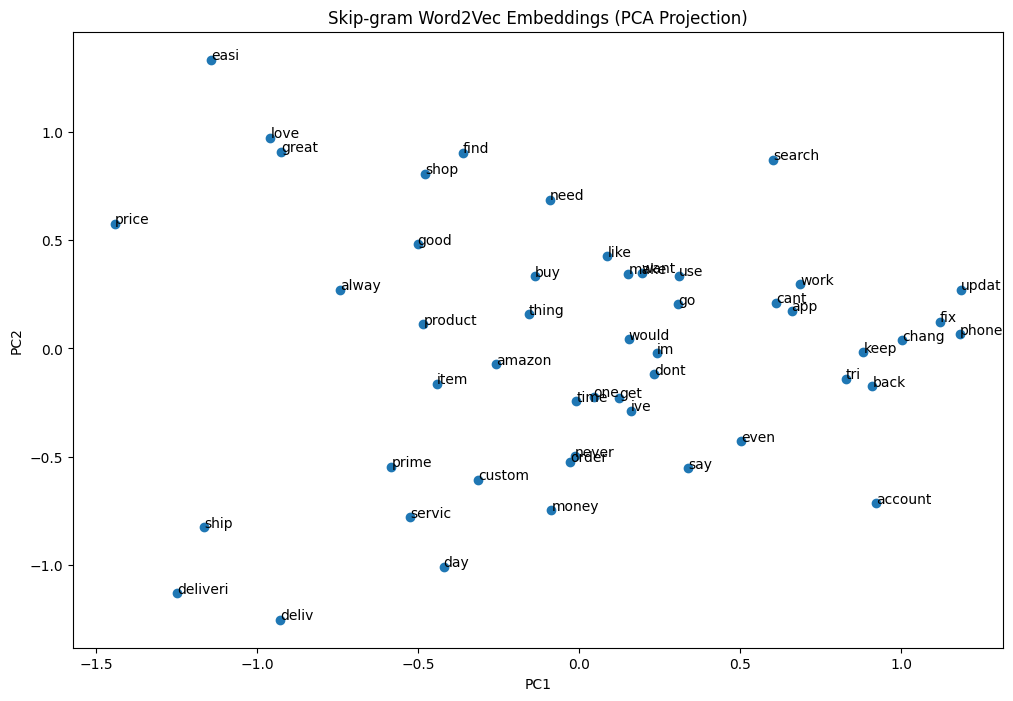

In [ ]:
# Top frequent words from vocab (first 50 words)
words = list(skipgram_model.wv.key_to_index.keys())[:50]
vectors = np.array([skipgram_model.wv[w] for w in words])

pca = PCA(n_components=2)
coords = pca.fit_transform(vectors)

plt.figure(figsize=(12, 8))
plt.scatter(coords[:, 0], coords[:, 1])

for i, w in enumerate(words):
    plt.annotate(w, (coords[i, 0], coords[i, 1]))

plt.title("Skip-gram Word2Vec Embeddings (PCA Projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

### **TASK 4:**

In [ ]:
# Bag of Words
from sklearn.feature_extraction.text import CountVectorizer

bow_vectorizer = CountVectorizer(max_features=3000)
X_bow = bow_vectorizer.fit_transform(df['final_text'])

X_bow.shape

(82449, 3000)

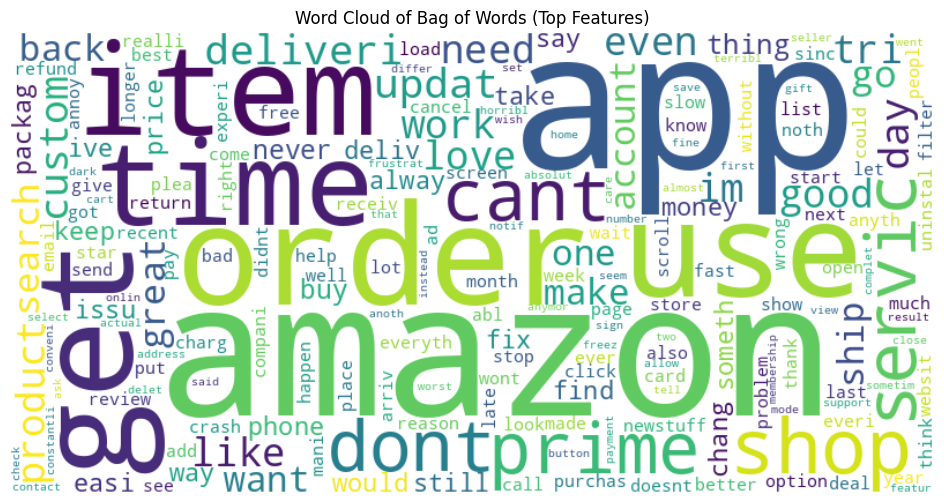

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import numpy as np

# Get word frequencies (summary counts across all reviews)
word_counts = np.asarray(X_bow.sum(axis=0)).flatten()
words = bow_vectorizer.get_feature_names_out()

bow_frequencies = dict(zip(words, word_counts))

# WordCloud from BoW frequencies
wordcloud = WordCloud(background_color='white', width=800, height=400)\
    .generate_from_frequencies(bow_frequencies)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Bag of Words (Top Features)")
plt.show()

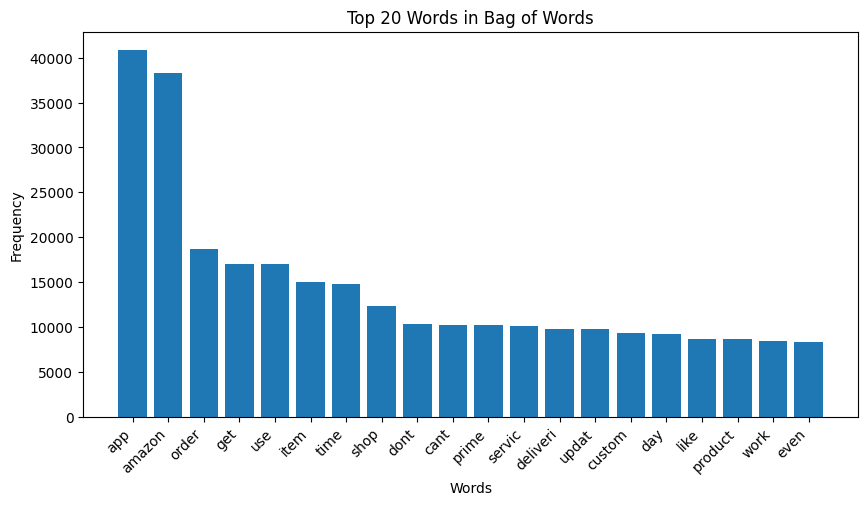

In [ ]:
# Visualize top words
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

word_counts = np.asarray(X_bow.sum(axis=0)).ravel()
words = np.array(bow_vectorizer.get_feature_names_out())

top_n = 20
top_idx = word_counts.argsort()[-top_n:][::-1]

top_words = words[top_idx]
top_counts = word_counts[top_idx]

plt.figure(figsize=(10,5))
plt.bar(top_words, top_counts)
plt.xticks(rotation=45, ha='right')
plt.title("Top 20 Words in Bag of Words")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

In [ ]:
# N-Gram
ngram_vectorizer = CountVectorizer(ngram_range=(1,2), max_features=4000)
X_ngrams = ngram_vectorizer.fit_transform(df['final_text'])

X_ngrams.shape

(82449, 4000)

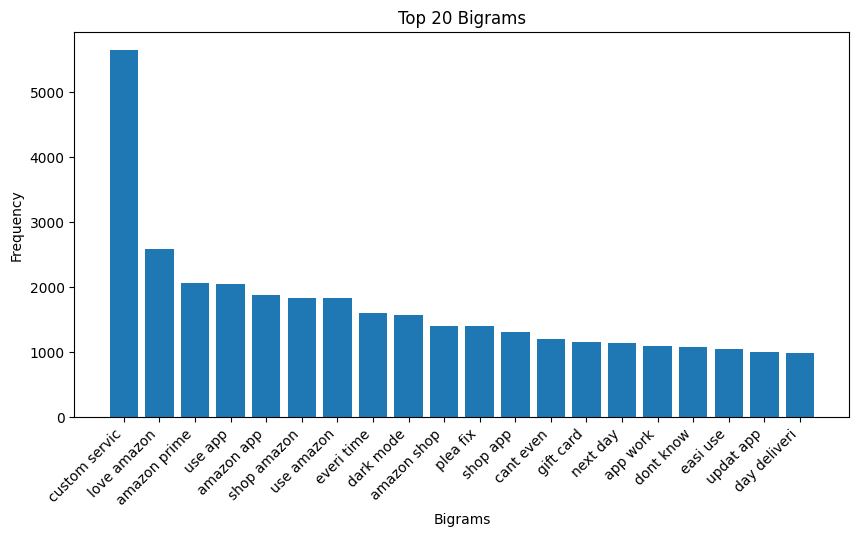

In [ ]:
# Visualize Bigram
ngram_counts = np.asarray(X_ngrams.sum(axis=0)).ravel()
ngrams = np.array(ngram_vectorizer.get_feature_names_out())

# filter only bigrams (contain space)
bigram_mask = np.char.find(ngrams.astype(str), " ") >= 0
bigrams = ngrams[bigram_mask]
bigram_counts = ngram_counts[bigram_mask]

top_n = 20
top_idx = bigram_counts.argsort()[-top_n:][::-1]

plt.figure(figsize=(10,5))
plt.bar(bigrams[top_idx], bigram_counts[top_idx])
plt.xticks(rotation=45, ha='right')
plt.title("Top 20 Bigrams")
plt.xlabel("Bigrams")
plt.ylabel("Frequency")
plt.show()

In [ ]:
# POS Tagging
import nltk
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

from nltk import pos_tag
from nltk.tokenize import word_tokenize

# 3 sample reviews for demonstration
sample_texts = df['final_text'].dropna().sample(3, random_state=42).tolist()

for i, text in enumerate(sample_texts, 1):
    tokens = word_tokenize(text)
    tagged = pos_tag(tokens)
    print(f"\n--- Sample Review {i} ---")
    print(tagged[:30])  # show first 30 tags

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!



--- Sample Review 1 ---
[('high', 'JJ'), ('price', 'NN')]

--- Sample Review 2 ---
[('freez', 'NN'), ('constantli', 'NN'), ('sinc', 'NN'), ('last', 'JJ'), ('updat', 'JJ'), ('headach', 'NN'), ('plea', 'NN'), ('fix', 'NN')]

--- Sample Review 3 ---
[('instal', 'JJ'), ('app', 'NN'), ('work', 'NN'), ('ok', 'JJ'), ('turn', 'VBP'), ('phone', 'NN'), ('amazon', 'NN'), ('app', 'NN'), ('fulli', 'NN'), ('disappear', 'VBP'), ('reinstal', 'JJ'), ('app', 'NN')]


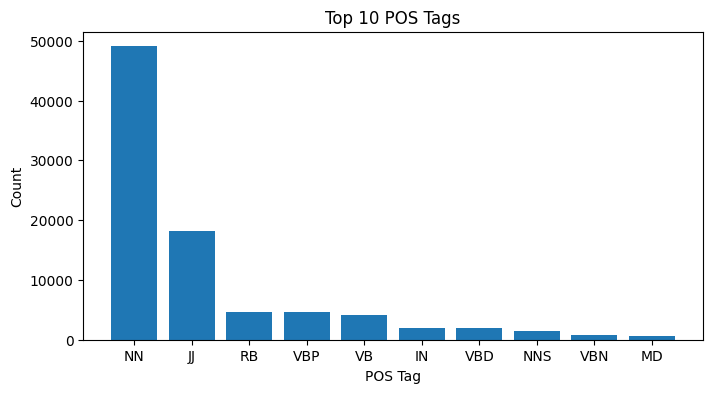

In [ ]:
# POS Visualization
from collections import Counter

all_pos = []
for text in df['final_text'].dropna().sample(5000, random_state=42):  # sample to keep it fast
    tokens = word_tokenize(text)
    all_pos.extend([tag for _, tag in pos_tag(tokens)])

pos_counts = Counter(all_pos)
top_pos = pos_counts.most_common(10)

labels, values = zip(*top_pos)

plt.figure(figsize=(8,4))
plt.bar(labels, values)
plt.title("Top 10 POS Tags")
plt.xlabel("POS Tag")
plt.ylabel("Count")
plt.show()

In [ ]:
# NER
import spacy

# Load small English model
try:
    nlp = spacy.load("en_core_web_sm")
except:
    import spacy.cli
    spacy.cli.download("en_core_web_sm")
    nlp = spacy.load("en_core_web_sm")

# Run NER on a few samples
ner_samples = df['content'].dropna().sample(3, random_state=7).tolist()

for i, text in enumerate(ner_samples, 1):
    doc = nlp(text)
    ents = [(ent.text, ent.label_) for ent in doc.ents]
    print(f"\n--- NER Sample {i} ---")
    print(ents)



--- NER Sample 1 ---
[]

--- NER Sample 2 ---
[]

--- NER Sample 3 ---
[('7', 'CARDINAL'), ('LG G5', 'ORG'), ('LG G8', 'ORG'), ('9', 'CARDINAL'), ('midday', 'TIME'), ('Alexa', 'ORG')]


In [ ]:
from spacy import displacy
doc = nlp("I bought an Apple iPhone in Bahrain on July 2025 and returned it back to Amazon.")
print([(ent.text, ent.label_) for ent in doc.ents])
displacy.render(doc, style="ent", jupyter=True)

[('Apple iPhone', 'ORG'), ('Bahrain', 'GPE'), ('July 2025', 'DATE'), ('Amazon', 'ORG')]


**TASK 5:**

In [ ]:
# Labelling
def sentiment_label(score):
    if score <= 2:
        return 'Negative'
    elif score == 3:
        return 'Neutral'
    else:
        return 'Positive'

df['sentiment'] = df['score'].apply(sentiment_label)

df[['score', 'sentiment']].head()


,score,sentiment
0,5,Positive
1,1,Negative
2,5,Positive
3,2,Negative
4,5,Positive


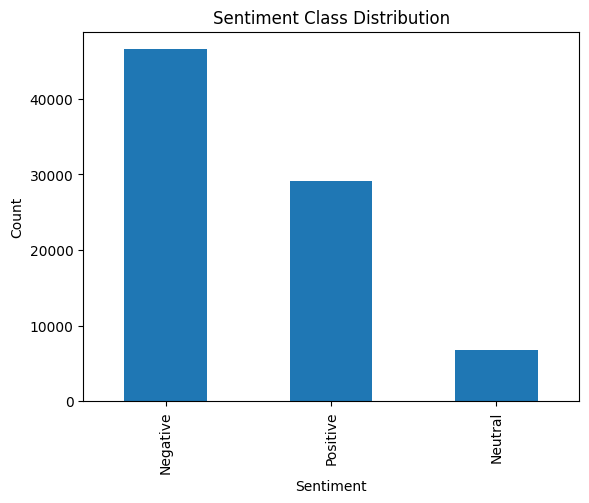

In [ ]:
# Labelling Visualization
import matplotlib.pyplot as plt

df['sentiment'].value_counts().plot(kind='bar')
plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

In [ ]:
# Train-Test Split
from sklearn.model_selection import train_test_split

X = df['final_text']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
#TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [ ]:
# Naive Bayes
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

y_pred_nb = nb_model.predict(X_test_tfidf)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.8250454821103699
              precision    recall  f1-score   support

    Negative       0.79      0.97      0.87      9309
     Neutral       0.32      0.01      0.01      1362
    Positive       0.91      0.78      0.84      5819

    accuracy                           0.83     16490
   macro avg       0.67      0.59      0.57     16490
weighted avg       0.79      0.83      0.79     16490



In [ ]:
# Logestic Regression
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)

y_pred_lr = lr_model.predict(X_test_tfidf)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.8389326864766525
              precision    recall  f1-score   support

    Negative       0.83      0.94      0.88      9309
     Neutral       0.29      0.03      0.06      1362
    Positive       0.87      0.86      0.86      5819

    accuracy                           0.84     16490
   macro avg       0.66      0.61      0.60     16490
weighted avg       0.80      0.84      0.81     16490



**TASK 6:**

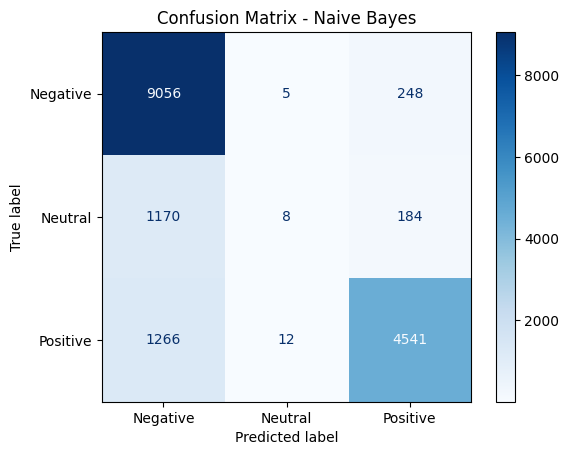

In [ ]:
# Confusion Matrix Naive Bayes
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_nb = confusion_matrix(y_test, y_pred_nb, labels=['Negative','Neutral','Positive'])

disp_nb = ConfusionMatrixDisplay(
    confusion_matrix=cm_nb,
    display_labels=['Negative','Neutral','Positive']
)

disp_nb.plot(cmap='Blues')
plt.title("Confusion Matrix - Naive Bayes")
plt.show()

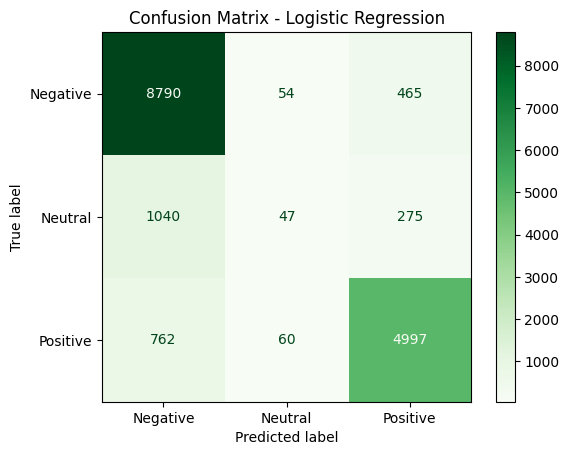

In [ ]:
# Confusion Martix Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr, labels=['Negative','Neutral','Positive'])

disp_lr = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=['Negative','Neutral','Positive']
)

disp_lr.plot(cmap='Greens')
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [ ]:
!pip install pyspellchecker
from spellchecker import SpellChecker

spell = SpellChecker()
def correct_spellings(text):
    corrected_text = []
    misspelled_words = spell.unknown(text.split())
    for word in text.split():
        if word in misspelled_words:
            corrected_text.append(spell.correction(word))
        else:
            corrected_text.append(word)
    return " ".join(corrected_text)

In [ ]:
text = "thnks for readin the my final projject notebook"
correct_spellings(text)

'thanks for reading the my final project notebook'